# Notebook 06 — Chemical Reactions: Encoding Transformations Computationally

In the wet lab, you communicate reactions by drawing arrow-pushing mechanisms on a whiteboard — electrons flow from nucleophile to electrophile, bonds break and form, and products emerge. **Reaction SMARTS** encode exactly the same transformations, but in a machine-readable string format.

With reaction SMARTS we can:
- **Apply reaction templates** to molecules and generate products programmatically
- **Validate** whether a given transformation is chemically plausible
- **Enumerate combinatorial libraries** — the computational equivalent of parallel synthesis

This notebook bridges the gap between the curly-arrow mechanisms you know from organic chemistry and RDKit's reaction handling API. Each named reaction includes a brief mechanism refresher so you can see exactly how the SMARTS pattern maps to the electron flow you'd draw on paper.

In [2]:
from rdkit import Chem
from rdkit.Chem import AllChem, Draw, rdChemReactions

## 1. Reaction SMARTS — Arrow-Pushing in a String

### Chemistry refresher

When you draw a mechanism on paper, you track specific atoms through a transformation: *this* carbon gets attacked, *that* oxygen loses a proton. **Reaction SMARTS** do the same thing with **atom mapping numbers**.

**Format:** `reactant1.reactant2>>product1.product2`

- The `>>` arrow separates reactants (left) from products (right), just like the reaction arrow you draw.
- Multiple reactants/products on the same side are separated by `.` (disconnection).
- **Atom maps** like `[C:1]` assign a tracking number (`:1`) to an atom. The same number on the product side tells RDKit "this is the same atom after the reaction." Think of it as labeling atoms with colored stickers before and after the transformation.

### Key difference from SMILES
Regular SMILES describes a single molecule's connectivity. Reaction SMARTS describes a *transformation pattern* — it can match any molecule that has the right functional group, just like a general mechanism applies to an entire reaction class.

In [3]:
# Simple ester hydrolysis: ester + water -> carboxylic acid + alcohol
# Mechanism reminder: nucleophilic addition-elimination at the carbonyl carbon.
# Water attacks the C=O, the tetrahedral intermediate collapses, and the OR group leaves.
#
# In SMARTS:  [C:1](=[O:2])[O:3][C:4] >> [C:1](=[O:2])[OH] . [C:4][OH]
#   :1 = carbonyl carbon   :2 = carbonyl oxygen
#   :3 = ester oxygen (bridge)   :4 = alkyl carbon on the alcohol side

rxn_smarts = "[C:1](=[O:2])[O:3][C:4]>>[C:1](=[O:2])[OH].[C:4][OH]"
rxn = rdChemReactions.ReactionFromSmarts(rxn_smarts)

print(f"Num reactant templates: {rxn.GetNumReactantTemplates()}")
print(f"Num product templates:  {rxn.GetNumProductTemplates()}")

Num reactant templates: 1
Num product templates:  2


## 2. Running Reactions — From Template to Products

### Chemistry refresher

`RunReactants` applies the reaction template to actual molecules. It works like a pattern-matching engine: RDKit finds every substructure in the input molecule that matches the reactant template and generates a product for each match.

**Why multiple product sets?** If a molecule has two ester groups, the template matches twice — one product set per match site. This mirrors real-world **regiochemistry/selectivity** issues: both sites *can* react, and computationally we get all possibilities. In the lab, you'd rely on steric/electronic effects to favor one site; here, you need to filter programmatically.

**Important:** Products from `RunReactants` are not sanitized by default. You must call `Chem.SanitizeMol()` to clean up implicit hydrogens, aromaticity perception, etc. Think of it as "purifying" your computational product.

In [4]:
# Apply ester hydrolysis to ethyl acetate (CH3-CO-O-CH2CH3)
ethyl_acetate = Chem.MolFromSmiles("CC(=O)OCC")
products = rxn.RunReactants((ethyl_acetate,))

print(f"Number of product sets: {len(products)}")
for i, prod_set in enumerate(products):
    print(f"\nProduct set {i}:")
    for p in prod_set:
        Chem.SanitizeMol(p)
        print(f"  {Chem.MolToSmiles(p)}")

Number of product sets: 1

Product set 0:
  CC(=O)O
  CCO


[22:45:19] mapped atoms in the reactants were not mapped in the products.
  unmapped numbers are: 3 


In [5]:
# What happens with a molecule that has TWO ester groups?
# Diethyl malonate: EtOOC-CH2-COOEt — two ester sites, so we expect multiple product sets.
diethyl_malonate = Chem.MolFromSmiles("CCOC(=O)CC(=O)OCC")
products_multi = rxn.RunReactants((diethyl_malonate,))

print(f"Number of product sets: {len(products_multi)}")
for i, prod_set in enumerate(products_multi):
    print(f"\nProduct set {i}:")
    for p in prod_set:
        Chem.SanitizeMol(p)
        print(f"  {Chem.MolToSmiles(p)}")

print("\n--- Takeaway ---")
print("Multiple product sets = multiple reactive sites.")
print("In the lab you'd control selectivity; computationally you get all possibilities.")

Number of product sets: 2

Product set 0:
  CCOC(=O)CC(=O)O
  CCO

Product set 1:
  CCOC(=O)CC(=O)O
  CCO

--- Takeaway ---
Multiple product sets = multiple reactive sites.
In the lab you'd control selectivity; computationally you get all possibilities.


## 3. Named Reactions — A Computational Toolkit

Below we encode several workhorse reactions from medicinal and synthetic chemistry as reaction SMARTS. Each one includes a brief mechanism refresher so you can see how the SMARTS maps to the arrow-pushing you already know.

---

### 3a. Amide Coupling (Carboxylic Acid + Amine --> Amide + H2O)

**Mechanism refresher:** In the lab, coupling reagents (EDC, HATU, etc.) activate the carboxylic acid, making the carbonyl carbon more electrophilic. The amine nitrogen then attacks the activated carbonyl, forming a tetrahedral intermediate that collapses to release the leaving group and give the amide bond.

In our SMARTS template, we skip the activation step and directly encode the net transformation: the OH of the acid is replaced by the NH of the amine.

In [6]:
# Amide coupling: R-COOH + H2N-R' -> R-CONHR' + H2O
amide_coupling = rdChemReactions.ReactionFromSmarts(
    "[C:1](=[O:2])[OH].[N:3]([H])([H])[C:4]>>[C:1](=[O:2])[N:3]([H])[C:4]"
)

# Test with benzoic acid + methylamine
acid = Chem.MolFromSmiles("c1ccc(C(=O)O)cc1")   # benzoic acid
amine = Chem.MolFromSmiles("CN")                  # methylamine

products = amide_coupling.RunReactants((acid, amine))
for ps in products:
    for p in ps:
        Chem.SanitizeMol(p)
        print(f"Amide product: {Chem.MolToSmiles(p)}")

### 3b. Suzuki Coupling (Aryl Halide + Boronic Acid --> Biaryl)

**Mechanism refresher:** The Suzuki reaction is a Pd(0)-catalyzed cross-coupling. The catalytic cycle involves:
1. **Oxidative addition** — Pd(0) inserts into the C-Br bond of the aryl halide, forming an Ar-Pd(II)-Br complex.
2. **Transmetalation** — The boronic acid transfers its aryl group to Pd, replacing Br (assisted by base).
3. **Reductive elimination** — The two aryl groups on Pd couple together, regenerating Pd(0) and releasing the biaryl product.

Our SMARTS simply encodes the net bond-forming event: Ar-Br + Ar'-B(OH)2 --> Ar-Ar'. The catalyst and base are implicit.

In [7]:
# Suzuki coupling: Ar-Br + Ar'-B(OH)2 -> Ar-Ar'
suzuki = rdChemReactions.ReactionFromSmarts(
    "[c:1][Br].[c:2][B]([OH])[OH]>>[c:1][c:2]"
)

aryl_br = Chem.MolFromSmiles("c1ccc(Br)cc1")       # bromobenzene
boronic = Chem.MolFromSmiles("c1ccc(B(O)O)cc1")    # phenylboronic acid

products = suzuki.RunReactants((aryl_br, boronic))
for ps in products:
    for p in ps:
        Chem.SanitizeMol(p)
        print(f"Suzuki product: {Chem.MolToSmiles(p)}")
        # Expected: biphenyl (c1ccc(-c2ccccc2)cc1)

Suzuki product: c1ccc(-c2ccccc2)cc1
Suzuki product: c1ccc(-c2ccccc2)cc1


### 3c. Reductive Amination (Aldehyde/Ketone + Amine --> Amine via Imine)

**Mechanism refresher:** Reductive amination is a two-step, one-pot process you've likely run many times:
1. **Imine (Schiff base) formation** — The amine nitrogen attacks the carbonyl carbon, water is lost, and a C=N imine forms.
2. **Reduction** — NaBH3CN or NaBH(OAc)3 selectively reduces the C=N to C-N (without touching the starting ketone, which is why you use a mild reductant).

Our SMARTS encodes the **net** transformation: C=O + H2N-R --> CH-NHR (carbonyl becomes a methylene bearing the amine). We skip the imine intermediate and the reduction step — just the overall bond changes.

In [ ]:
# Reductive amination: R-CHO + H2N-R' -> R-CH2-NHR'
# Net transformation: carbonyl oxygen removed, C-N bond formed, C gets an extra H
reductive_amination = rdChemReactions.ReactionFromSmarts(
    "[C:1](=[O])[H].[N:2]([H])[H]>>[C:1][N:2]"
)

# Test: benzaldehyde + aniline -> N-benzylaniline
benzaldehyde = Chem.MolFromSmiles("O=Cc1ccccc1")   # benzaldehyde
aniline = Chem.MolFromSmiles("Nc1ccccc1")           # aniline

products = reductive_amination.RunReactants((benzaldehyde, aniline))
for ps in products:
    for p in ps:
        Chem.SanitizeMol(p)
        print(f"Reductive amination product: {Chem.MolToSmiles(p)}")

### 3d. Nucleophilic Aromatic Substitution (SNAr)

**Mechanism refresher:** SNAr requires an **electron-poor aromatic ring** (activated by electron-withdrawing groups like -NO2, -CN, or -F at ortho/para positions). The mechanism is an **addition-elimination**:
1. The nucleophile (e.g., an amine or alkoxide) attacks the ring carbon bearing the leaving group, forming a **Meisenheimer complex** (a resonance-stabilized anionic intermediate — the ring temporarily loses aromaticity).
2. The leaving group (typically F, Cl) departs, restoring aromaticity.

Fluorine is the best leaving group for SNAr (counterintuitive if you're thinking SN2!) because the rate-determining step is nucleophilic *addition*, and C-F has the most polarized bond (highest delta+ on carbon), making it most electrophilic.

Our SMARTS template encodes the displacement of F on an aromatic ring by a primary amine.

In [8]:
# SNAr: Ar-F + H2N-R -> Ar-NHR + HF
# Template: fluorine on aromatic carbon displaced by primary amine
snar = rdChemReactions.ReactionFromSmarts(
    "[c:1][F].[N:2]([H])[H]>>[c:1][N:2]([H])"
)

# Test: 2,4-dinitrofluorobenzene (Sanger's reagent!) + methylamine
dnfb = Chem.MolFromSmiles("O=[N+]([O-])c1ccc(F)c([N+](=O)[O-])c1")  # 2,4-DNFB
methylamine = Chem.MolFromSmiles("CN")

products = snar.RunReactants((dnfb, methylamine))
for ps in products:
    for p in ps:
        Chem.SanitizeMol(p)
        print(f"SNAr product: {Chem.MolToSmiles(p)}")

print("\n(Sanger used this exact reaction to determine the N-terminal amino acid of insulin!)")


(Sanger used this exact reaction to determine the N-terminal amino acid of insulin!)


## 4. Library Enumeration — Computational Parallel Synthesis

### Chemistry refresher

In medicinal chemistry, **combinatorial / parallel synthesis** is how you explore SAR (structure-activity relationships): you fix a core scaffold and systematically vary substituents at one or more positions. A classic example is making a matrix of amides from *m* acids and *n* amines, giving you *m x n* compounds in one campaign.

Computationally, we do the same thing: iterate over building block sets and apply a reaction template to each combination. The result is a **virtual library** — you can screen it computationally (docking, property filters, ML models) before committing to actual synthesis, saving weeks of lab time.

Below we enumerate a 3x3 amide coupling library.

In [9]:
# Define building blocks: 3 carboxylic acids x 3 primary amines
acids = [
    Chem.MolFromSmiles("c1ccc(C(=O)O)cc1"),         # benzoic acid
    Chem.MolFromSmiles("CC(=O)O"),                    # acetic acid
    Chem.MolFromSmiles("OC(=O)c1ccc(F)cc1"),          # 4-fluorobenzoic acid
]
acid_names = ["benzoic acid", "acetic acid", "4-fluorobenzoic acid"]

amines = [
    Chem.MolFromSmiles("NCC"),                         # ethylamine
    Chem.MolFromSmiles("NC1CCCCC1"),                   # cyclohexylamine
    Chem.MolFromSmiles("NCc1ccccc1"),                  # benzylamine
]
amine_names = ["ethylamine", "cyclohexylamine", "benzylamine"]

# Enumerate all combinations
products_list = []
labels = []

for i, acid in enumerate(acids):
    for j, amine in enumerate(amines):
        ps = amide_coupling.RunReactants((acid, amine))
        if ps:
            p = ps[0][0]
            Chem.SanitizeMol(p)
            products_list.append(p)
            smi = Chem.MolToSmiles(p)
            label = f"{acid_names[i]} + {amine_names[j]}"
            labels.append(label)
            print(f"{label:45s} -> {smi}")

print(f"\nTotal products enumerated: {len(products_list)}")


Total products enumerated: 0


In [10]:
# Visualize the library as a grid — like looking at your compound plate
Draw.MolsToGridImage(
    products_list,
    molsPerRow=3,
    subImgSize=(300, 250),
    legends=labels,
)

[22:46:51] 

****
Pre-condition Violation
no draw context
Violation occurred on line 211 in file /Users/runner/work/rdkit-pypi/rdkit-pypi/build/temp.macosx-11.0-arm64-cpython-314/rdkit/Code/GraphMol/MolDraw2D/MolDraw2DCairo.cpp
Failed Expression: dp_cr
****



RuntimeError: Pre-condition Violation
	no draw context
	Violation occurred on line 211 in file Code/GraphMol/MolDraw2D/MolDraw2DCairo.cpp
	Failed Expression: dp_cr
	RDKIT: 2025.09.6
	BOOST: 1_85


## 5. Visualizing Reaction Schemes

RDKit can render a reaction template as an image — reactants on the left, arrow in the middle, products on the right. This is useful for documentation, reports, or verifying that your SMARTS pattern encodes the transformation you intended.

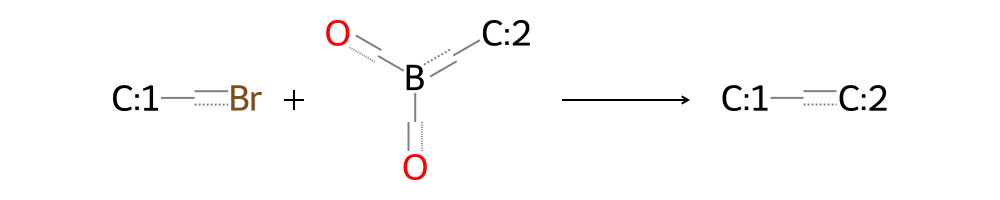

In [11]:
# Draw the Suzuki coupling reaction scheme
suzuki_rxn = rdChemReactions.ReactionFromSmarts(
    "[c:1][Br].[c:2][B]([OH])[OH]>>[c:1][c:2]"
)
img = Draw.ReactionToImage(suzuki_rxn, subImgSize=(250, 200))
img

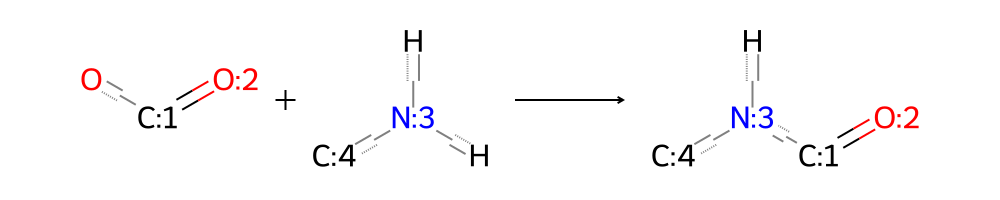

In [12]:
# Draw the amide coupling reaction scheme
amide_rxn_vis = rdChemReactions.ReactionFromSmarts(
    "[C:1](=[O:2])[OH].[N:3]([H])([H])[C:4]>>[C:1](=[O:2])[N:3]([H])[C:4]"
)
Draw.ReactionToImage(amide_rxn_vis, subImgSize=(250, 200))

Reductive amination:


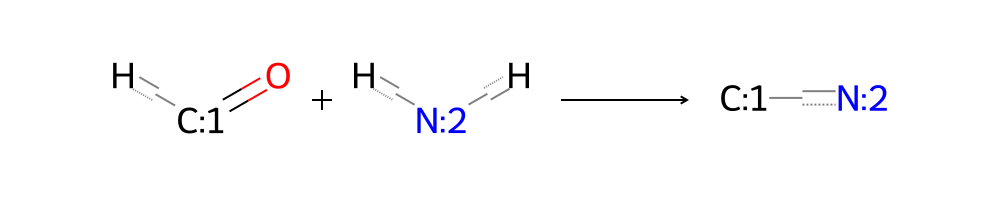


SNAr:


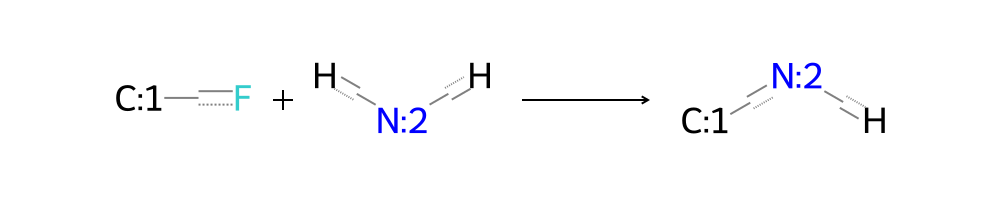

In [13]:
# Draw the reductive amination and SNAr schemes side by side
print("Reductive amination:")
red_am_vis = rdChemReactions.ReactionFromSmarts(
    "[C:1](=[O])[H].[N:2]([H])[H]>>[C:1][N:2]"
)
display(Draw.ReactionToImage(red_am_vis, subImgSize=(250, 200)))

print("\nSNAr:")
snar_vis = rdChemReactions.ReactionFromSmarts(
    "[c:1][F].[N:2]([H])[H]>>[c:1][N:2]([H])"
)
display(Draw.ReactionToImage(snar_vis, subImgSize=(250, 200)))

## 6. Summary

### What we covered

| Concept | Wet-lab analogy | RDKit equivalent |
|---|---|---|
| Reaction SMARTS | Arrow-pushing mechanism drawn on paper | `rdChemReactions.ReactionFromSmarts()` — encodes atom-tracked transformations |
| Atom mapping (`[C:1]`) | Labeling atoms with colored stickers | Tracking numbers that persist from reactants to products |
| `RunReactants` | Running the reaction in a flask | Pattern-matching + product generation; multiple product sets = multiple reactive sites |
| `SanitizeMol` | Purifying your product (column, recrystallization) | Cleaning up valences, aromaticity, implicit H's |
| Library enumeration | Parallel/combinatorial synthesis (plate-based) | Nested loops over building blocks + reaction template |
| Reaction visualization | Drawing the scheme in your notebook | `Draw.ReactionToImage()` |

### Named reactions encoded
- **Amide coupling** — carboxylic acid + amine (EDC/HATU chemistry)
- **Suzuki coupling** — aryl halide + boronic acid (Pd-catalyzed)
- **Reductive amination** — aldehyde + amine (NaBH3CN reduction)
- **SNAr** — activated Ar-F + nucleophilic amine

### Key takeaways
1. Reaction SMARTS are **general templates** — they apply to any molecule matching the pattern, just like a mechanism applies to a reaction class.
2. Always **sanitize** products after `RunReactants`.
3. Watch for **multiple product sets** when molecules have multiple matching sites.
4. Combinatorial enumeration lets you explore chemical space computationally before committing to synthesis.

### Up next
**Notebook 07** will build on these reaction tools to explore retrosynthetic analysis and more advanced reaction handling (multi-step sequences, reaction filtering, and SMARTS validation).